In [106]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
from sklearn.model_selection import train_test_split
import math
from scipy.stats.mstats import winsorize

In [107]:
train_df = pd.read_csv("Datast/train.csv")
test_df = pd.read_csv("Datast/test.csv")
building_df = pd.read_csv("Datast/building_metadata.csv")
weather_train_df = pd.read_csv("Datast/weather_train.csv")
weather_test_df = pd.read_csv("Datast/weather_test.csv")

In [108]:
weat_cop=weather_train_df.copy()
test_weat_cop=weather_test_df.copy()

In [109]:
weat_cop.describe()

,site_id,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
count,139773.000000,139718.000000,70600.000000,139660.000000,89484.000000,129155.000000,133505.000000,139469.000000
mean,7.478977,14.418106,2.149306,7.350158,0.983047,1016.158038,180.526632,3.560527
std,4.604744,10.626595,2.599150,9.790235,8.463678,7.629684,111.523629,2.335874
min,0.000000,-28.900000,0.000000,-35.000000,-1.000000,968.200000,0.000000,0.000000
25%,3.000000,7.200000,0.000000,0.600000,0.000000,1011.800000,80.000000,2.100000
50%,7.000000,15.000000,2.000000,8.300000,0.000000,1016.400000,190.000000,3.100000
75%,11.000000,22.200000,4.000000,14.400000,0.000000,1020.800000,280.000000,5.000000
max,15.000000,47.200000,9.000000,26.100000,343.000000,1045.500000,360.000000,19.000000


In [110]:
missing_percentage = weat_cop.isnull().sum() / len(weat_cop) * 100
missing_percentage

site_id                0.000000
timestamp              0.000000
air_temperature        0.039350
cloud_coverage        49.489529
dew_temperature        0.080845
precip_depth_1_hr     35.979052
sea_level_pressure     7.596603
wind_direction         4.484414
wind_speed             0.217496
dtype: float64

In [111]:
weat_cop.head()

,site_id,timestamp,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
0,0,2016-01-01 00:00:00,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
1,0,2016-01-01 01:00:00,24.4,NaN,21.1,-1.0,1020.2,70.0,1.5
2,0,2016-01-01 02:00:00,22.8,2.0,21.1,0.0,1020.2,0.0,0.0
3,0,2016-01-01 03:00:00,21.1,2.0,20.6,0.0,1020.1,0.0,0.0
4,0,2016-01-01 04:00:00,20.0,2.0,20.0,-1.0,1020.0,250.0,2.6


In [112]:
weat_cop.isnull().sum()

site_id                   0
timestamp                 0
air_temperature          55
cloud_coverage        69173
dew_temperature         113
precip_depth_1_hr     50289
sea_level_pressure    10618
wind_direction         6268
wind_speed              304
dtype: int64

In [113]:
def saturation_vapor_pressure(temperature):
    return 6.112 * math.exp((17.67 * temperature) / (temperature + 243.5))

# Function to calculate relative humidity
def relative_humidity(air_temp, dew_temp):
    E_air = saturation_vapor_pressure(air_temp)
    E_dew = saturation_vapor_pressure(dew_temp)
    RH = (E_dew / E_air) * 100
    return RH

# Apply the function to each row in the dataframe to calculate relative humidity
weat_cop['relative_humidity'] = weat_cop.apply(lambda row: relative_humidity(row['air_temperature'], row['dew_temperature']), axis=1)
test_weat_cop['relative_humidity'] = test_weat_cop.apply(lambda row: relative_humidity(row['air_temperature'], row['dew_temperature']), axis=1)

In [114]:
# Simplified heat index (Rothfusz regression approximation)
weat_cop['heat_index'] = (
    0.5 * (weat_cop['air_temperature'] + 61.0 + 
    (weat_cop['air_temperature'] - 68.0) * 1.2 + 
    weat_cop['dew_temperature'] * 0.094
)
)

# Wind chill (for temps < 10°C and wind > 4.8 km/h)
mask = (weat_cop['air_temperature'] < 10) & (weat_cop['wind_speed'] > 1.34)  # 1.34 m/s ≈ 4.8 km/h
weat_cop['wind_chill'] = (
    13.12 + 0.6215 * weat_cop['air_temperature'] - 
    11.37 * (weat_cop['wind_speed'] ** 0.16) + 
    0.3965 * weat_cop['air_temperature'] * (weat_cop['wind_speed'] ** 0.16)
)
weat_cop['wind_chill'] = weat_cop['wind_chill'].where(mask, weat_cop['air_temperature'])

weat_cop['feels_like'] = np.where(
    weat_cop['air_temperature'] >= 27,  # Hot threshold
    weat_cop['heat_index'],
    np.where(
        weat_cop['air_temperature'] <= 10,  # Cold threshold
        weat_cop['wind_chill'],
        weat_cop['air_temperature']  # Default
    )
)

#Test

test_weat_cop['heat_index'] = (
    0.5 * (test_weat_cop['air_temperature'] + 61.0 + 
    (test_weat_cop['air_temperature'] - 68.0) * 1.2 + 
    test_weat_cop['dew_temperature'] * 0.094
)
)

# Wind chill (for temps < 10°C and wind > 4.8 km/h)
mask = (test_weat_cop['air_temperature'] < 10) & (test_weat_cop['wind_speed'] > 1.34)  # 1.34 m/s ≈ 4.8 km/h
test_weat_cop['wind_chill'] = (
    13.12 + 0.6215 * test_weat_cop['air_temperature'] - 
    11.37 * (test_weat_cop['wind_speed'] ** 0.16) + 
    0.3965 * test_weat_cop['air_temperature'] * (test_weat_cop['wind_speed'] ** 0.16)
)
test_weat_cop['wind_chill'] = test_weat_cop['wind_chill'].where(mask, test_weat_cop['air_temperature'])

test_weat_cop['feels_like'] = np.where(
    test_weat_cop['air_temperature'] >= 27,  # Hot threshold
    test_weat_cop['heat_index'],
    np.where(
        test_weat_cop['air_temperature'] <= 10,  # Cold threshold
        test_weat_cop['wind_chill'],
        test_weat_cop['air_temperature']  # Default
    )
)

In [115]:
import numpy as np
import pandas as pd

# Assuming weat_cop is your weather dataframe
weat_cop["timestamp"] = pd.to_datetime(weat_cop["timestamp"])

# Extract basic time features
weat_cop["hour"] = weat_cop["timestamp"].dt.hour
weat_cop["day_of_week"] = weat_cop["timestamp"].dt.weekday  # Monday=0, Sunday=6
weat_cop["month"] = weat_cop["timestamp"].dt.month
weat_cop["day_of_year"] = weat_cop["timestamp"].dt.dayofyear
weat_cop["is_weekend"] = (weat_cop["day_of_week"] >= 5).astype(int)

# Cyclical encoding for hour
weat_cop["hour_sin"] = np.sin(2 * np.pi * weat_cop["hour"] / 24)
weat_cop["hour_cos"] = np.cos(2 * np.pi * weat_cop["hour"] / 24)

# Cyclical encoding for day of the week
weat_cop["day_sin"] = np.sin(2 * np.pi * weat_cop["day_of_week"] / 7)
weat_cop["day_cos"] = np.cos(2 * np.pi * weat_cop["day_of_week"] / 7)

# Cyclical encoding for month
weat_cop["month_sin"] = np.sin(2 * np.pi * weat_cop["month"] / 12)
weat_cop["month_cos"] = np.cos(2 * np.pi * weat_cop["month"] / 12)

# Season encoding (0: Winter, 1: Spring, 2: Summer, 3: Fall)
weat_cop["season"] = weat_cop["month"].map(lambda m: 0 if m in [12, 1, 2] else
                                         1 if m in [3, 4, 5] else
                                         2 if m in [6, 7, 8] else 3)

# Drop original timestamp column if no longer needed
# weat_cop.drop(columns=["timestamp"], inplace=True)


#test

import numpy as np
import pandas as pd

# Assuming weat_cop is your weather dataframe
test_weat_cop["timestamp"] = pd.to_datetime(test_weat_cop["timestamp"])

# Extract basic time features
test_weat_cop["hour"] = test_weat_cop["timestamp"].dt.hour
test_weat_cop["day_of_week"] = test_weat_cop["timestamp"].dt.weekday  # Monday=0, Sunday=6
test_weat_cop["month"] = test_weat_cop["timestamp"].dt.month
test_weat_cop["day_of_year"] = test_weat_cop["timestamp"].dt.dayofyear
test_weat_cop["is_weekend"] = (test_weat_cop["day_of_week"] >= 5).astype(int)

# Cyclical encoding for hour
test_weat_cop["hour_sin"] = np.sin(2 * np.pi * test_weat_cop["hour"] / 24)
test_weat_cop["hour_cos"] = np.cos(2 * np.pi * test_weat_cop["hour"] / 24)

# Cyclical encoding for day of the week
test_weat_cop["day_sin"] = np.sin(2 * np.pi * test_weat_cop["day_of_week"] / 7)
test_weat_cop["day_cos"] = np.cos(2 * np.pi * test_weat_cop["day_of_week"] / 7)

# Cyclical encoding for month
test_weat_cop["month_sin"] = np.sin(2 * np.pi * test_weat_cop["month"] / 12)
test_weat_cop["month_cos"] = np.cos(2 * np.pi * test_weat_cop["month"] / 12)

# Season encoding (0: Winter, 1: Spring, 2: Summer, 3: Fall)
test_weat_cop["season"] = test_weat_cop["month"].map(lambda m: 0 if m in [12, 1, 2] else
                                         1 if m in [3, 4, 5] else
                                         2 if m in [6, 7, 8] else 3)

# Drop original timestamp column if no longer needed
# weat_cop.drop(columns=["timestamp"], inplace=True)

# Display updated dataframe
weat_cop.head()


,site_id,timestamp,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed,relative_humidity,...,month,day_of_year,is_weekend,hour_sin,hour_cos,day_sin,day_cos,month_sin,month_cos,season
0,0,2016-01-01 00:00:00,25.0,6.0,20.0,NaN,1019.7,0.0,0.0,73.780558,...,1,1,0,0.000000,1.000000,-0.433884,-0.900969,0.5,0.866025,0
1,0,2016-01-01 01:00:00,24.4,NaN,21.1,-1.0,1020.2,70.0,1.5,81.848292,...,1,1,0,0.258819,0.965926,-0.433884,-0.900969,0.5,0.866025,0
2,0,2016-01-01 02:00:00,22.8,2.0,21.1,0.0,1020.2,0.0,0.0,90.139994,...,1,1,0,0.500000,0.866025,-0.433884,-0.900969,0.5,0.866025,0
3,0,2016-01-01 03:00:00,21.1,2.0,20.6,0.0,1020.1,0.0,0.0,96.968347,...,1,1,0,0.707107,0.707107,-0.433884,-0.900969,0.5,0.866025,0
4,0,2016-01-01 04:00:00,20.0,2.0,20.0,-1.0,1020.0,250.0,2.6,100.000000,...,1,1,0,0.866025,0.500000,-0.433884,-0.900969,0.5,0.866025,0


In [116]:

T_min = -10  # Below this, heating load is maxed
T_max = 35   # Above this, cooling load is maxed

weat_cop['feels_like_capped'] = weat_cop['feels_like'].clip(T_min, T_max)
test_weat_cop['feels_like_capped'] = test_weat_cop['feels_like'].clip(T_min, T_max)
# weat_cop['feels_like_capped']

In [117]:

weat_cop['precip_depth_1_hr'] = (
    weat_cop['precip_depth_1_hr']
    .replace(-1.0, np.nan)
    .interpolate(method='linear', limit=6)  # 6-hour gap limit
    .fillna(0)  # Fill remaining gaps with 0
)

#test

test_weat_cop['precip_depth_1_hr'] = (
    test_weat_cop['precip_depth_1_hr']
    .replace(-1.0, np.nan)
    .interpolate(method='linear', limit=6)  # 6-hour gap limit
    .fillna(0)  # Fill remaining gaps with 0
)

In [118]:
bins = [-0.1, 0.1, 5.0, 15.0, float('inf')]  # -0.1 to catch near-zero values  
labels = ['No Rain', 'Light Rain', 'Moderate Rain', 'Heavy Rain']  

weat_cop['precip_1h_category'] = pd.cut(
    weat_cop['precip_depth_1_hr'],  
    bins=bins,  
    labels=labels  
)

#test

bins = [-0.1, 0.1, 5.0, 15.0, float('inf')]  # -0.1 to catch near-zero values  
labels = ['No Rain', 'Light Rain', 'Moderate Rain', 'Heavy Rain']  

test_weat_cop['precip_1h_category'] = pd.cut(
    test_weat_cop['precip_depth_1_hr'],  
    bins=bins,  
    labels=labels  
)

In [119]:

weat_cop['no_rain'] = (weat_cop['precip_depth_1_hr'] == 0).astype(int)
test_weat_cop['no_rain'] = (test_weat_cop['precip_depth_1_hr'] == 0).astype(int)  

weat_cop['is_light_rain'] = (weat_cop['precip_depth_1_hr'] > 0.1).astype(int)  
test_weat_cop['is_light_rain'] = (test_weat_cop['precip_depth_1_hr'] > 0.1).astype(int)  

weat_cop['is_moderate_rain'] = ((weat_cop['precip_depth_1_hr'] > 5.0) & (weat_cop['precip_depth_1_hr'] < 15.0)).astype(int)
test_weat_cop['is_moderate_rain'] = ((test_weat_cop['precip_depth_1_hr'] > 5.0) & (test_weat_cop['precip_depth_1_hr'] < 15.0)).astype(int)

weat_cop['is_heavy_rain'] = (weat_cop['precip_depth_1_hr'] >= 15.0).astype(int)  
test_weat_cop['is_heavy_rain'] = (test_weat_cop['precip_depth_1_hr'] >= 15.0).astype(int)  

In [120]:

weat_cop["sea_level_pressure"] = winsorize(weat_cop["sea_level_pressure"], limits=[0.01, 0.01])  # Capping at 0.5% on both ends
test_weat_cop["sea_level_pressure"] = winsorize(test_weat_cop["sea_level_pressure"], limits=[0.01, 0.01])  # Capping at 0.5% on both ends

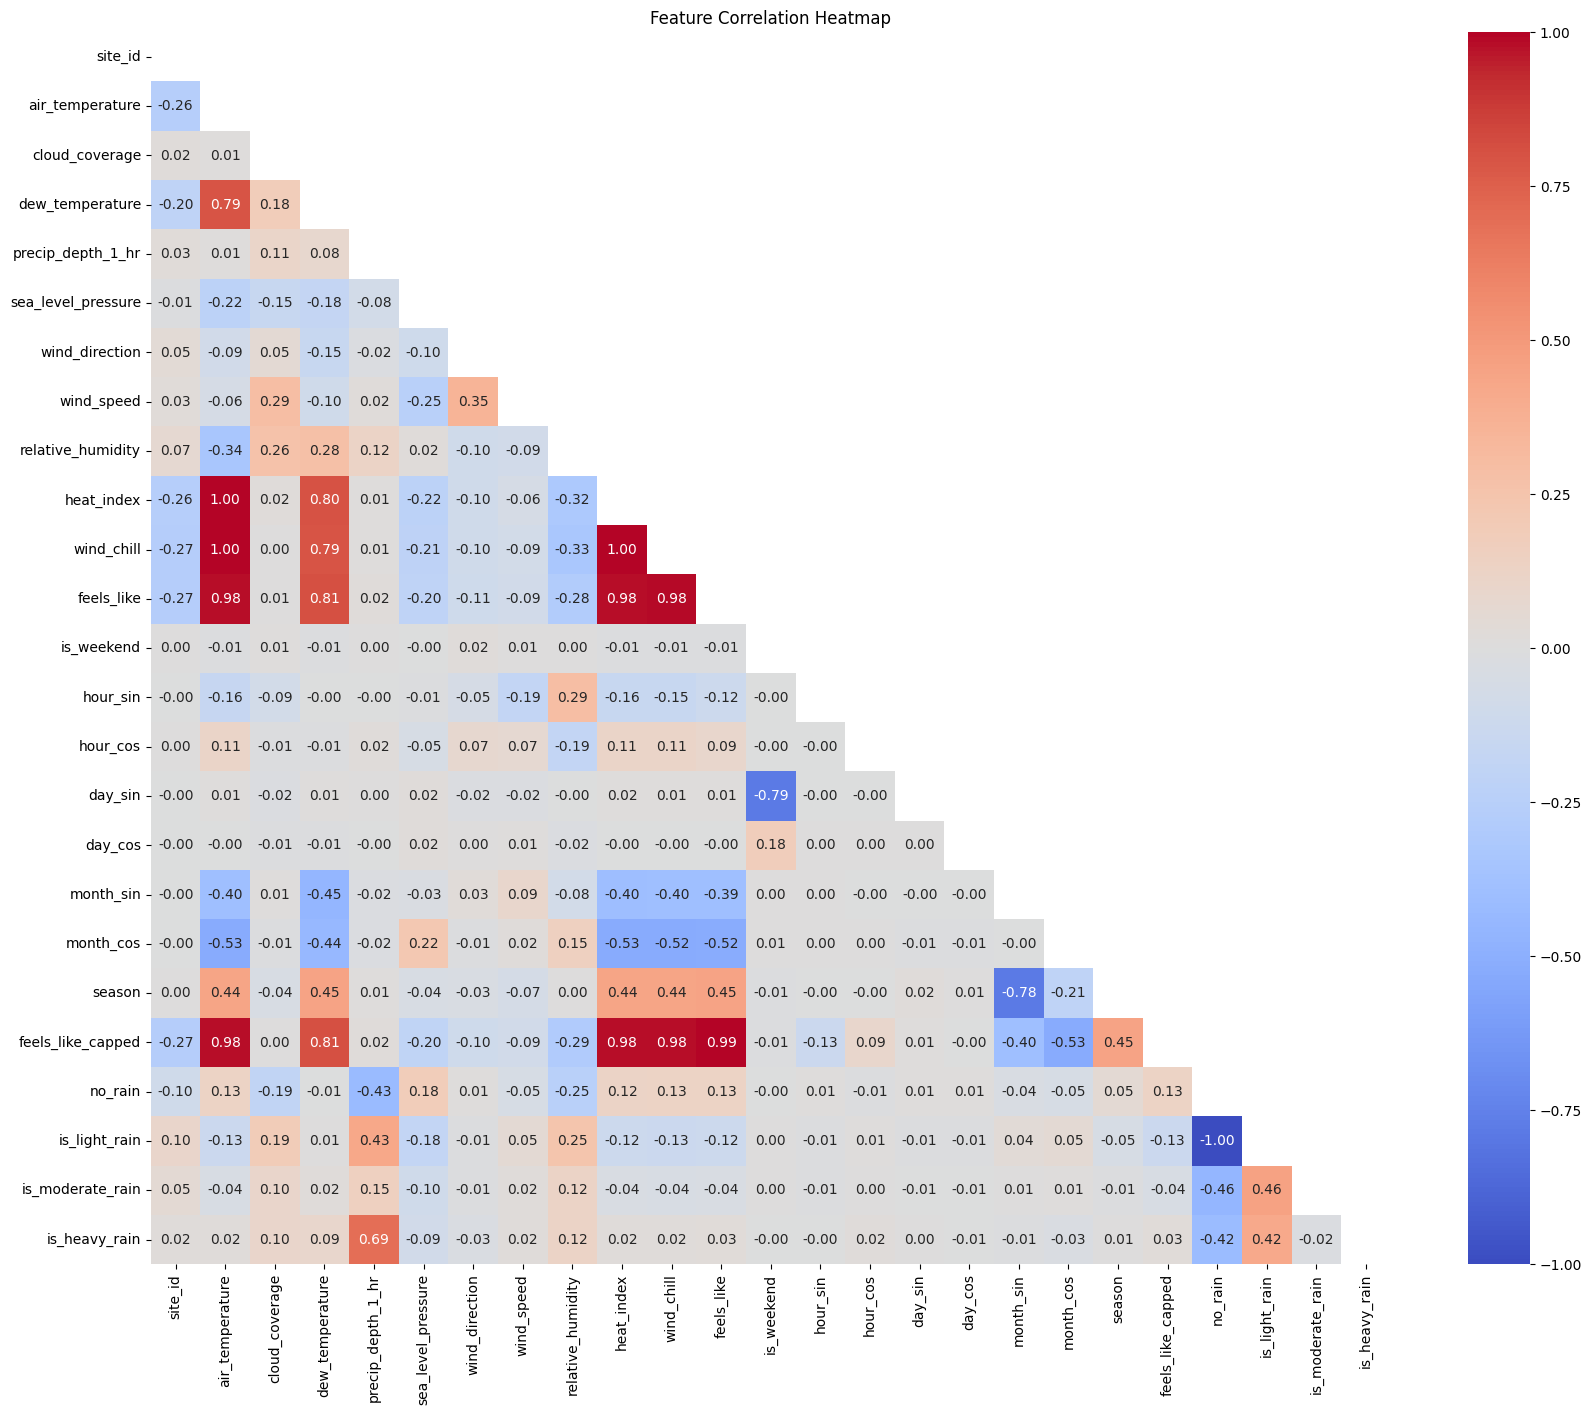

In [121]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = weat_cop.select_dtypes(include=['float64', 'int64']).columns
corr_df = weat_cop[numeric_cols].corr()

plt.figure(figsize=(20, 16))
sns.heatmap(
    corr_df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    mask=np.triu(np.ones_like(corr_df))  # Hide upper triangle for clarity
)
plt.title("Feature Correlation Heatmap")
plt.show()

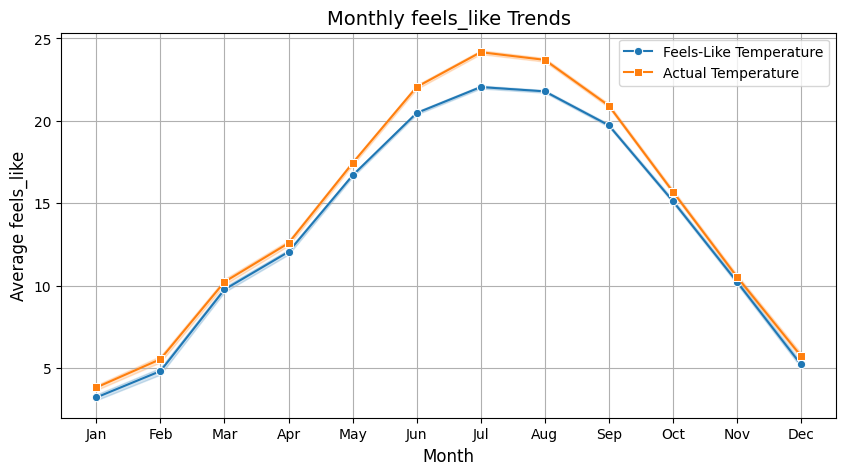

In [122]:
monthly_readings = weat_cop.groupby("month")["feels_like"].mean()

# Plot
plt.figure(figsize=(10, 5))
# sns.lineplot(x=monthly_readings.index, y=monthly_readings.values, marker="o", linestyle="-", color="b")
sns.lineplot(data=weat_cop, x='month', y='feels_like', label='Feels-Like Temperature', marker='o')
sns.lineplot(data=weat_cop, x='month', y='air_temperature', label='Actual Temperature', marker='s')

# Labels and title
plt.xlabel("Month", fontsize=12)
plt.ylabel("Average feels_like", fontsize=12)
plt.title("Monthly feels_like Trends", fontsize=14)
plt.xticks(range(1, 13), ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
plt.grid(True)

# Show plot
plt.show()

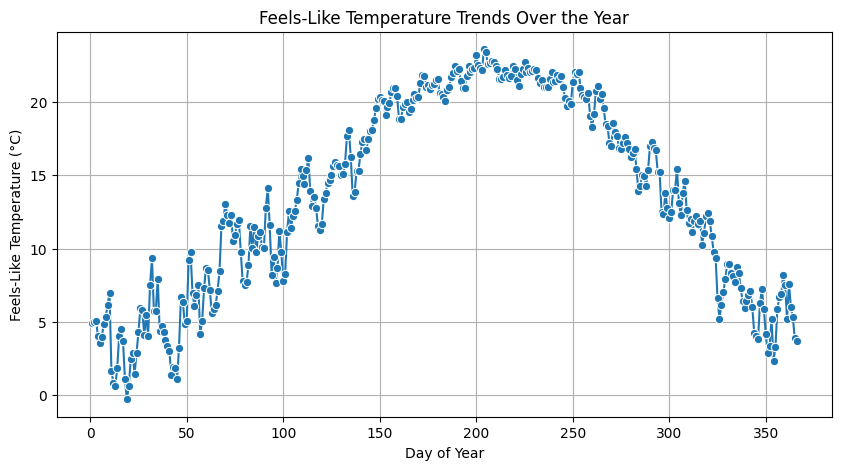

In [123]:
# Final_weat.columns

df_daily = weat_cop.groupby('day_of_year')['feels_like_capped'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=df_daily, x='day_of_year', y='feels_like_capped', marker='o')
plt.xlabel('Day of Year')
plt.ylabel('Feels-Like Temperature (°C)')
plt.title('Feels-Like Temperature Trends Over the Year')
plt.grid()
plt.show()


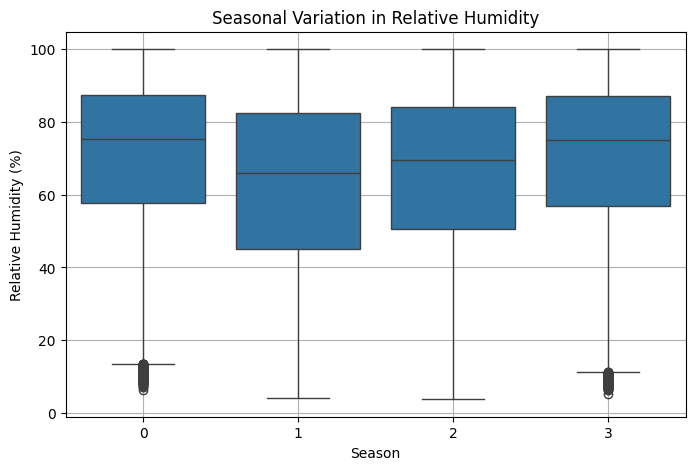

In [124]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=weat_cop, x='season', y='relative_humidity')
plt.xlabel('Season')
plt.ylabel('Relative Humidity (%)')
plt.title('Seasonal Variation in Relative Humidity')
plt.grid()
plt.show()


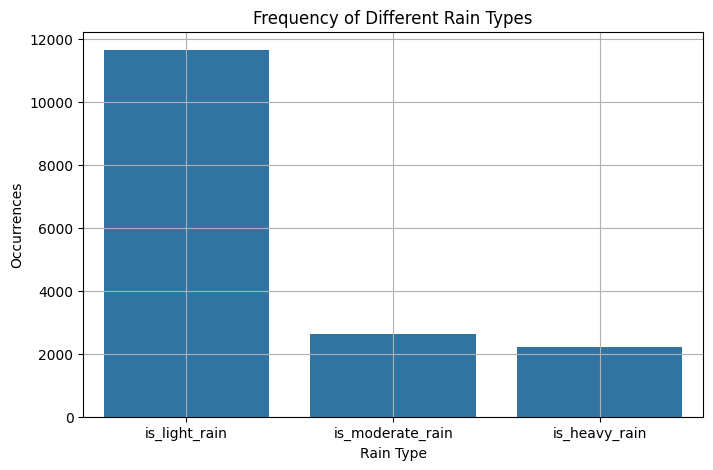

In [125]:
rain_counts = weat_cop[['is_light_rain', 'is_moderate_rain', 'is_heavy_rain']].sum()

plt.figure(figsize=(8, 5))
sns.barplot(x=rain_counts.index, y=rain_counts.values)
plt.xlabel('Rain Type')
plt.ylabel('Occurrences')
plt.title('Frequency of Different Rain Types')
plt.grid()
plt.show()


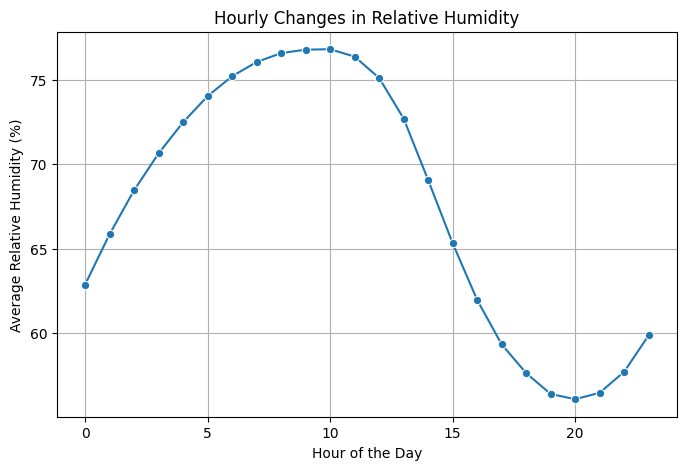

In [126]:
df_hourly = weat_cop.groupby('hour')['relative_humidity'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.lineplot(data=df_hourly, x='hour', y='relative_humidity', marker='o')
plt.xlabel('Hour of the Day')
plt.ylabel('Average Relative Humidity (%)')
plt.title('Hourly Changes in Relative Humidity')
plt.grid()
plt.show()


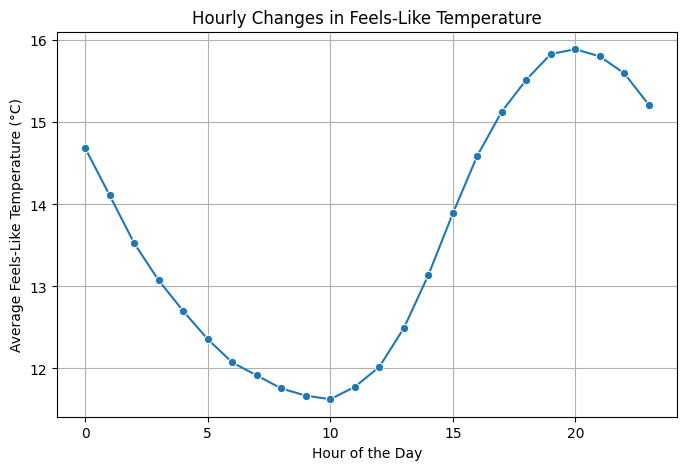

In [127]:

df_hourly = weat_cop.groupby('hour')['feels_like_capped'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.lineplot(data=df_hourly, x='hour', y='feels_like_capped', marker='o')
plt.xlabel('Hour of the Day')
plt.ylabel('Average Feels-Like Temperature (°C)')
plt.title('Hourly Changes in Feels-Like Temperature')
plt.grid()
plt.show()


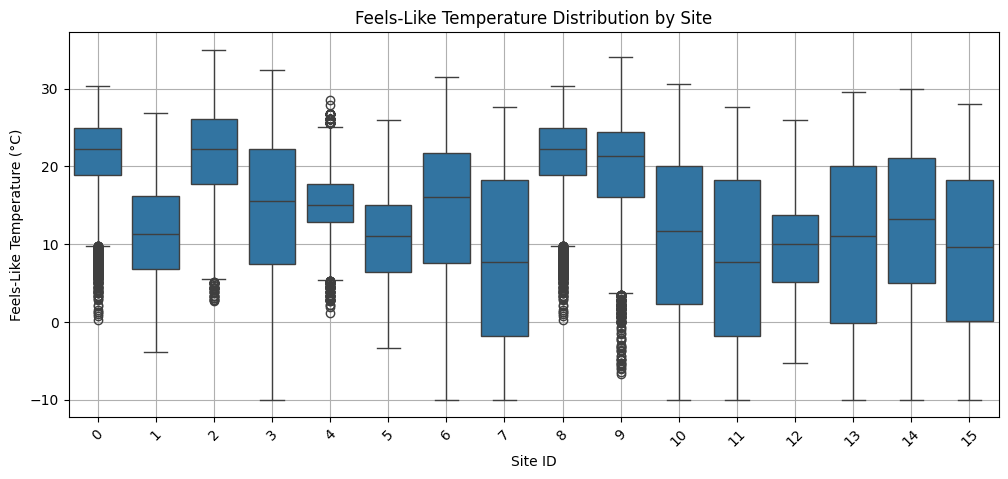

In [128]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=weat_cop, x='site_id', y='feels_like_capped')
plt.xlabel('Site ID')
plt.ylabel('Feels-Like Temperature (°C)')
plt.title('Feels-Like Temperature Distribution by Site')
plt.xticks(rotation=45)
plt.grid()
plt.show()


In [129]:
weat_cop[['feels_like_capped', 'relative_humidity', 'wind_speed']] = (
    weat_cop[['feels_like_capped', 'relative_humidity', 'wind_speed']].interpolate(method="linear")
)


In [130]:
selected_features = [
    "site_id","relative_humidity", "feels_like_capped", "wind_speed", "precip_1h_category", "is_light_rain", "is_moderate_rain", "is_heavy_rain", 
    'hour', 'day_of_week', 'month', 'day_of_year',
       'is_weekend', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'month_sin',
       'month_cos', 'season','timestamp'
]

In [131]:
Final_weat_train=weat_cop[selected_features]

In [132]:
buil_cop=building_df.copy()

In [133]:
buil_cop.describe()

,site_id,building_id,square_feet,year_built,floor_count
count,1449.000000,1449.000000,1449.000000,675.000000,355.000000
mean,6.952381,724.000000,92111.776398,1967.957037,3.740845
std,5.003432,418.434583,110769.950997,31.054030,3.333683
min,0.000000,0.000000,283.000000,1900.000000,1.000000
25%,3.000000,362.000000,23012.000000,1949.000000,1.000000
50%,5.000000,724.000000,57673.000000,1970.000000,3.000000
75%,13.000000,1086.000000,115676.000000,1995.000000,5.000000
max,15.000000,1448.000000,875000.000000,2017.000000,26.000000


In [134]:
buil_cop.isnull().sum()

site_id           0
building_id       0
primary_use       0
square_feet       0
year_built      774
floor_count    1094
dtype: int64

In [135]:
buil_cop['floor_count'].value_counts()

floor_count
1.0     109
2.0      67
4.0      37
3.0      33
5.0      25
6.0      25
8.0      19
7.0      14
9.0       8
11.0      5
10.0      4
13.0      2
12.0      2
16.0      1
14.0      1
21.0      1
26.0      1
19.0      1
Name: count, dtype: int64

In [136]:
buil_cop.drop(columns=['floor_count','year_built'],inplace=True)

Encoding primary type

In [137]:
label_encoder = LabelEncoder()

buil_cop['type_enc'] = label_encoder.fit_transform(buil_cop['primary_use'])


Converting sqaure feet to log values

In [138]:
buil_cop['square_feet_log'] = np.log1p(buil_cop['square_feet'])

dropping handled values

In [139]:
buil_cop.drop(columns=['primary_use','square_feet'],inplace=True)

In [140]:
train_merged = train_df.merge(buil_cop, on="building_id", how="left")
train_merged["timestamp"] = pd.to_datetime(train_merged["timestamp"])
Final_train = train_merged.merge(Final_weat_train, on=["site_id", "timestamp"], how="inner")
Final_train.shape

(20125605, 26)

In [141]:
Final_train.isna().sum()

building_id           0
meter                 0
timestamp             0
meter_reading         0
site_id               0
type_enc              0
square_feet_log       0
relative_humidity     0
feels_like_capped     0
wind_speed            0
precip_1h_category    0
is_light_rain         0
is_moderate_rain      0
is_heavy_rain         0
hour                  0
day_of_week           0
month                 0
day_of_year           0
is_weekend            0
hour_sin              0
hour_cos              0
day_sin               0
day_cos               0
month_sin             0
month_cos             0
season                0
dtype: int64

In [142]:
Final_train["meter_reading"] = np.log1p(Final_train["meter_reading"])

In [158]:
# test_merged = test_df.merge(buil_cop, on="building_id", how="left")
# test_merged["timestamp"] = pd.to_datetime(test_merged["timestamp"])
# Final_test = test_merged.merge(test_weat_cop, on=["site_id", "timestamp"], how="left")
# Final_test.shape

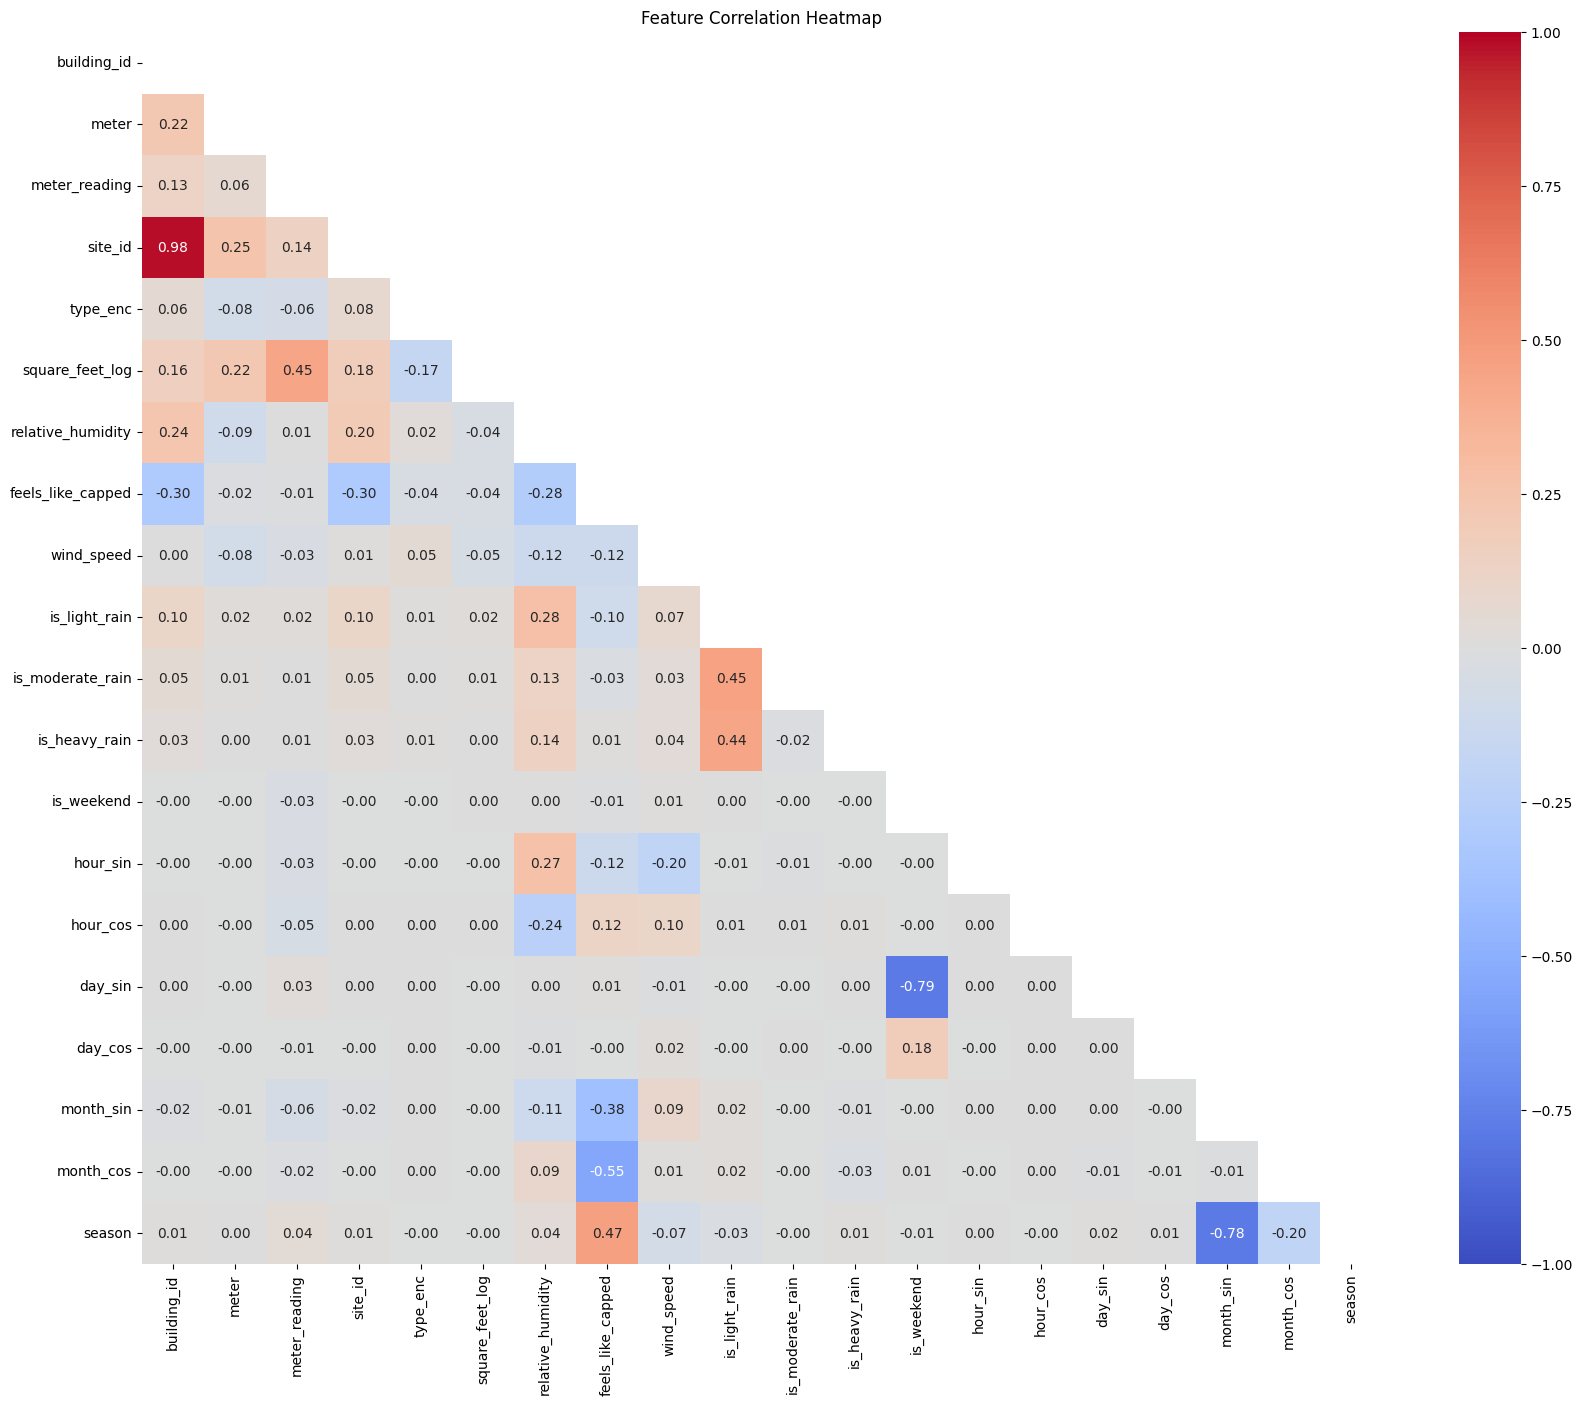

In [144]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = Final_train.select_dtypes(include=['float64', 'int64']).columns
corr_df = Final_train[numeric_cols].corr()

plt.figure(figsize=(20, 16))
sns.heatmap(
    corr_df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    mask=np.triu(np.ones_like(corr_df))  # Hide upper triangle for clarity
)
plt.title("Feature Correlation Heatmap")
plt.show()

In [145]:
# plt.scatter(Final_train['meter_reading'], Final_train['feels_like_capped'])
# plt.show()


In [146]:
Final_train.loc[(Final_train["site_id"] == 0) & (Final_train["meter"] == 0), "meter_reading"] *= 0.293071

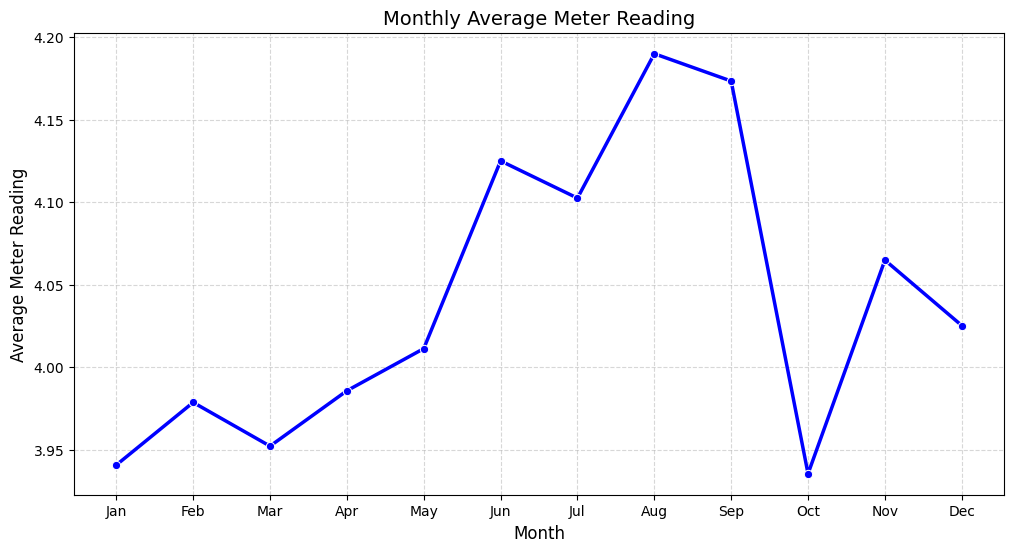

In [147]:
import matplotlib.pyplot as plt
import seaborn as sns

# ➤ Group data by month and calculate mean meter reading
monthly_reading = Final_train.groupby("month")["meter_reading"].mean()

# ➤ Plot the monthly meter reading trends
plt.figure(figsize=(12, 6))
sns.lineplot(x=monthly_reading.index, y=monthly_reading.values, marker="o", linewidth=2.5, color="blue")

# ➤ Labels & Title
plt.xlabel("Month", fontsize=12)
plt.ylabel("Average Meter Reading", fontsize=12)
plt.title("Monthly Average Meter Reading", fontsize=14)
plt.xticks(ticks=range(1, 13), labels=["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()


In [148]:
Final_train.dtypes

building_id                    int64
meter                          int64
timestamp             datetime64[ns]
meter_reading                float64
site_id                        int64
type_enc                       int64
square_feet_log              float64
relative_humidity            float64
feels_like_capped            float64
wind_speed                   float64
precip_1h_category          category
is_light_rain                  int64
is_moderate_rain               int64
is_heavy_rain                  int64
hour                           int32
day_of_week                    int32
month                          int32
day_of_year                    int32
is_weekend                     int64
hour_sin                     float64
hour_cos                     float64
day_sin                      float64
day_cos                      float64
month_sin                    float64
month_cos                    float64
season                         int64
dtype: object

In [149]:
Final_train['precip_1h_category_enc'] = label_encoder.fit_transform(Final_train['precip_1h_category'])
Final_train.drop(columns='precip_1h_category',inplace=True)

MODELS

Model 1 - lgbm

In [150]:
drop_0readings= list(Final_train[Final_train['meter_reading']==0.0].index)
Final_train.drop(drop_0readings, axis=0, inplace=True)
features=['building_id', 'meter', 'site_id',
       'type_enc', 'square_feet_log', 'relative_humidity', 'feels_like_capped',
       'wind_speed', 'is_light_rain', 'is_moderate_rain',
       'is_heavy_rain', 'hour', 'day_of_week', 'month', 'day_of_year',
       'is_weekend', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'month_sin',
       'month_cos', 'season']
target = "meter_reading"

X = Final_train[features]
y = Final_train[target]

# Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [151]:
def rmsle_lgbm(y_pred, data):

    y_true = np.array(data.get_label())
    score = np.sqrt(np.mean(np.power(np.log1p(y_true) - np.log1p(y_pred), 2)))

    return 'rmsle', score, False

In [152]:
params = {
    "objective": "regression",
    "boosting_type": "gbdt",
    "learning_rate": 0.05,
    "num_leaves": 51,
    "max_depth": -1,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "n_estimators": 1300,
    "verbose": -1
}

# Convert to LightGBM dataset
train_data = lgb.Dataset(X_train, label=y_train)
val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

# Train the model
# model = lgb.train(params, train_data, valid_sets=[val_data], early_stopping_rounds=50, verbose_eval=100)
model = lgb.train(
    params,
    train_data,
    valid_sets=[val_data],
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(100)],
    feval=rmsle_lgbm
)

Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 0.77593	valid_0's rmsle: 0.22213
[200]	valid_0's l2: 0.606636	valid_0's rmsle: 0.198614
[300]	valid_0's l2: 0.528213	valid_0's rmsle: 0.18591
[400]	valid_0's l2: 0.470959	valid_0's rmsle: 0.176033
[500]	valid_0's l2: 0.422593	valid_0's rmsle: 0.166865
[600]	valid_0's l2: 0.390387	valid_0's rmsle: 0.161067
[700]	valid_0's l2: 0.366657	valid_0's rmsle: 0.156948
[800]	valid_0's l2: 0.348148	valid_0's rmsle: 0.153095
[900]	valid_0's l2: 0.332605	valid_0's rmsle: 0.149733
[1000]	valid_0's l2: 0.315849	valid_0's rmsle: 0.146347
[1100]	valid_0's l2: 0.301744	valid_0's rmsle: 0.143301
[1200]	valid_0's l2: 0.292034	valid_0's rmsle: 0.141195
[1300]	valid_0's l2: 0.282485	valid_0's rmsle: 0.139055
Did not meet early stopping. Best iteration is:
[1300]	valid_0's l2: 0.282485	valid_0's rmsle: 0.139055


Training R² Score: 0.9161076061141268
Test R² Score: 0.9155730098532533


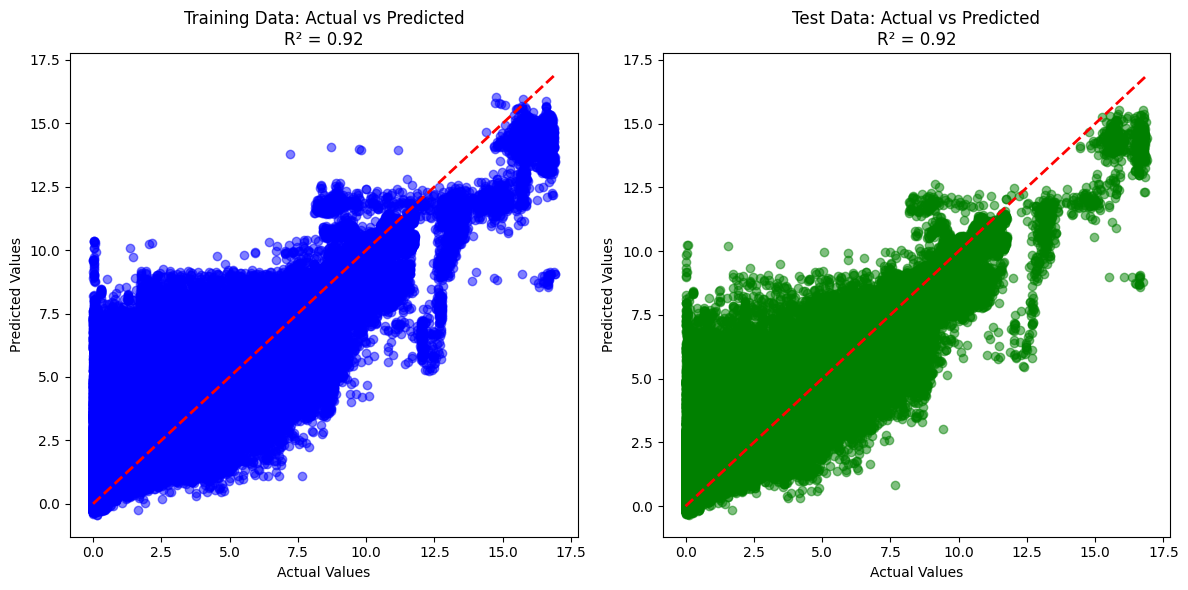

In [153]:
from sklearn.metrics import r2_score
# y_train_pred = model.predict(X_train)

# # Calculate R² Score
# r2 = r2_score(y_train, y_train_pred)
# print("Training R² Score:", r2)
# y_test_pred = model.predict(X_val)

# # Calculate R² Score
# r2_test = r2_score(y_val, y_test_pred)
# print("Test R² Score:", r2_test)

import matplotlib.pyplot as plt
import seaborn as sns

# Predictions for the training and test data
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_val)

# Calculate R² Scores
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_val, y_test_pred)

# Print R² Scores
print("Training R² Score:", r2_train)
print("Test R² Score:", r2_test)

# Plot for Training Data
plt.figure(figsize=(12, 6))

# Subplot 1: Actual vs Predicted for Training
plt.subplot(1, 2, 1)
plt.scatter(y_train, y_train_pred, color='blue', alpha=0.5)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(f'Training Data: Actual vs Predicted\nR² = {r2_train:.2f}')

# Subplot 2: Actual vs Predicted for Test Data
plt.subplot(1, 2, 2)
plt.scatter(y_val, y_test_pred, color='green', alpha=0.5)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(f'Test Data: Actual vs Predicted\nR² = {r2_test:.2f}')

plt.tight_layout()
plt.show()


LSTM

In [154]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

# Assume main_merged is your DataFrame and already loaded

# Normalize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reshape the data to simulate sequential (time-series) format (optional)
# If this is not time-series data and you want to work with LSTMs for sequence prediction
# you can treat it as sequences by adding a time axis (e.g., using sliding windows).

# Example: Reshaping into sequences (if needed)
sequence_length = 10  # You can change this based on your use case
generator = TimeseriesGenerator(X_scaled, y, length=sequence_length, batch_size=32)

# Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
# Reshape X_train and X_val to be 3D (samples, timesteps, features)
X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_val = X_val.reshape((X_val.shape[0], 1, X_val.shape[1]))

# Check the shape of the data after reshaping
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

# Initialize the model
model = Sequential()

# LSTM layer: input_shape should match (timesteps, features)
model.add(LSTM(units=64, activation='tanh', input_shape=(X_train.shape[1], X_train.shape[2])))

# Optionally add a Dropout layer to prevent overfitting
model.add(Dropout(0.2))

# Fully connected output layer
model.add(Dense(units=1))  # For regression, no activation function here

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Summary of the model to check the architecture
model.summary()


X_train shape: (14606174, 1, 23)
X_val shape: (3651544, 1, 23)


c:\Users\c24101927\ML_Project\ML_project\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 64)             │        22,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,593 (88.25 KB)

 Trainable params: 22,593 (88.25 KB)

 Non-trainable params: 0 (0.00 B)

In [155]:
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val))


Epoch 1/10
456443/456443 ━━━━━━━━━━━━━━━━━━━━ 595s 1ms/step - loss: 1.3495 - val_loss: 0.9352
Epoch 2/10
456443/456443 ━━━━━━━━━━━━━━━━━━━━ 606s 1ms/step - loss: 1.0092 - val_loss: 0.8698
Epoch 3/10
456443/456443 ━━━━━━━━━━━━━━━━━━━━ 590s 1ms/step - loss: 0.9618 - val_loss: 0.8414
Epoch 4/10
456443/456443 ━━━━━━━━━━━━━━━━━━━━ 575s 1ms/step - loss: 0.9374 - val_loss: 0.8148
Epoch 5/10
456443/456443 ━━━━━━━━━━━━━━━━━━━━ 592s 1ms/step - loss: 0.9185 - val_loss: 0.8030
Epoch 6/10
456443/456443 ━━━━━━━━━━━━━━━━━━━━ 579s 1ms/step - loss: 0.9037 - val_loss: 0.7897
Epoch 7/10
456443/456443 ━━━━━━━━━━━━━━━━━━━━ 575s 1ms/step - loss: 0.8951 - val_loss: 0.7790
Epoch 8/10
456443/456443 ━━━━━━━━━━━━━━━━━━━━ 581s 1ms/step - loss: 0.8870 - val_loss: 0.7687
Epoch 9/10
456443/456443 ━━━━━━━━━━━━━━━━━━━━ 579s 1ms/step - loss: 0.8793 - val_loss: 0.7645
Epoch 10/10
456443/456443 ━━━━━━━━━━━━━━━━━━━━ 584s 1ms/step - loss: 0.8744 - val_loss: 0.7563


456443/456443 ━━━━━━━━━━━━━━━━━━━━ 274s 599us/step
114111/114111 ━━━━━━━━━━━━━━━━━━━━ 74s 647us/step
Training R² Score: 0.774416382686121
Test R² Score: 0.7739598942268796


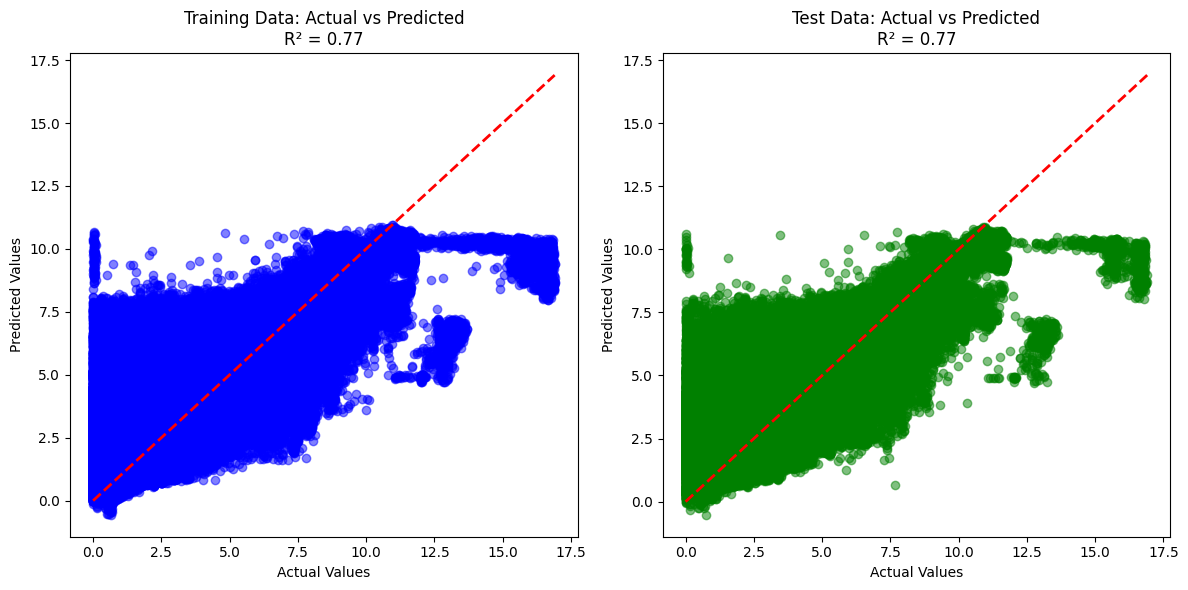

In [156]:
from sklearn.metrics import r2_score
# y_train_pred = model.predict(X_train)

# # Calculate R² Score
# r2 = r2_score(y_train, y_train_pred)
# print("Training R² Score:", r2)
# y_test_pred = model.predict(X_val)

# # Calculate R² Score
# r2_test = r2_score(y_val, y_test_pred)
# print("Test R² Score:", r2_test)

import matplotlib.pyplot as plt
import seaborn as sns

# Predictions for the training and test data
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_val)

# Calculate R² Scores
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_val, y_test_pred)

# Print R² Scores
print("Training R² Score:", r2_train)
print("Test R² Score:", r2_test)

# Plot for Training Data
plt.figure(figsize=(12, 6))

# Subplot 1: Actual vs Predicted for Training
plt.subplot(1, 2, 1)
plt.scatter(y_train, y_train_pred, color='blue', alpha=0.5)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(f'Training Data: Actual vs Predicted\nR² = {r2_train:.2f}')

# Subplot 2: Actual vs Predicted for Test Data
plt.subplot(1, 2, 2)
plt.scatter(y_val, y_test_pred, color='green', alpha=0.5)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(f'Test Data: Actual vs Predicted\nR² = {r2_test:.2f}')

plt.tight_layout()
plt.show()
